# 第 8 章 · 乳腺癌 MLP 分类代码实验

本页训练一个小型神经网络完成经典二分类任务。读者先看特征表，再看训练 loss 是否下降，最后看混淆矩阵和预测置信度。

[章节网页](../ch8.html)

## 运行内容

- 加载 Wisconsin 乳腺癌数据
- 训练 MLP 分类器
- 绘制 loss、混淆矩阵和预测置信度

## 0. 经典二分类数据

每行是一位样本的细胞核测量指标，模型根据这些特征预测良性或恶性类别。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 加载 Wisconsin 乳腺癌数据：这是二分类模型的经典公开案例。
cancer = load_breast_cancer(as_frame=True)
X_mlp = cancer.data
y_mlp = cancer.target

X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_mlp,
    y_mlp,
    test_size=0.25,
    stratify=y_mlp,
    random_state=8,
)

feature_preview = X_mlp[[
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
]].head(8)

cancer_summary = pd.DataFrame(
    {
        "样本数": [len(X_mlp)],
        "输入维度": [X_mlp.shape[1]],
        "类别数": [len(np.unique(y_mlp))],
        "训练样本": [len(X_train_mlp)],
        "测试样本": [len(X_test_mlp)],
        "类别名称": [", ".join(cancer.target_names)],
    }
)
display(cancer_summary)
display(feature_preview.round(3))

,样本数,输入维度,类别数,训练样本,测试样本,类别名称
0,569,30,2,426,143,"malignant, benign"


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,17.99,10.38,122.80,1001.0,0.118
1,20.57,17.77,132.90,1326.0,0.085
2,19.69,21.25,130.00,1203.0,0.110
3,11.42,20.38,77.58,386.1,0.142
4,20.29,14.34,135.10,1297.0,0.100
5,12.45,15.70,82.57,477.1,0.128
6,18.25,19.98,119.60,1040.0,0.095
7,13.71,20.83,90.20,577.9,0.119


## 1. 训练与预测

loss 曲线用于判断训练是否稳定，混淆矩阵用于找出最容易混淆的数字类别。

In [3]:
# 训练小型 MLP，并读取每轮 loss。
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        learning_rate_init=0.01,
        max_iter=80,
        random_state=8,
    ),
)

mlp.fit(X_train_mlp, y_train_mlp)
classifier = mlp.named_steps["mlpclassifier"]
mlp_trace = pd.DataFrame(
    {
        "轮次": np.arange(1, len(classifier.loss_curve_) + 1),
        "loss": classifier.loss_curve_,
    }
).round(4)

display(mlp_trace.iloc[[0, 1, 2, 9, 19, len(mlp_trace) - 1]])

,轮次,loss
0,1,0.8667
1,2,0.3210
2,3,0.2000
9,10,0.0711
19,20,0.0517
79,80,0.0166


In [4]:
# 查看测试集预测、准确率和混淆矩阵。
test_pred_mlp = mlp.predict(X_test_mlp)
test_prob_mlp = mlp.predict_proba(X_test_mlp)

score_df = pd.DataFrame(
    [{"数据": "Breast Cancer 测试集", "accuracy": accuracy_score(y_test_mlp, test_pred_mlp)}]
).round(3)
confusion_df = pd.DataFrame(
    confusion_matrix(y_test_mlp, test_pred_mlp),
    index=[f"真实_{name}" for name in cancer.target_names],
    columns=[f"预测_{name}" for name in cancer.target_names],
)
sample_result = pd.DataFrame(
    {
        "样本编号": X_test_mlp.index[:12],
        "真实": y_test_mlp.to_numpy()[:12],
        "预测": test_pred_mlp[:12],
        "预测置信度": np.max(test_prob_mlp[:12], axis=1),
    }
).round(3)

display(score_df)
display(sample_result)
display(confusion_df)

,数据,accuracy
0,Breast Cancer 测试集,0.972


,样本编号,真实,预测,预测置信度
0,142,1,1,1.000
1,163,1,1,0.999
2,183,1,1,1.000
3,13,0,1,0.588
4,504,1,1,1.000
5,193,0,0,1.000
6,206,1,1,1.000
7,271,1,1,1.000
8,124,1,1,1.000
9,15,0,0,1.000


,预测_malignant,预测_benign
真实_malignant,52,1
真实_benign,3,87


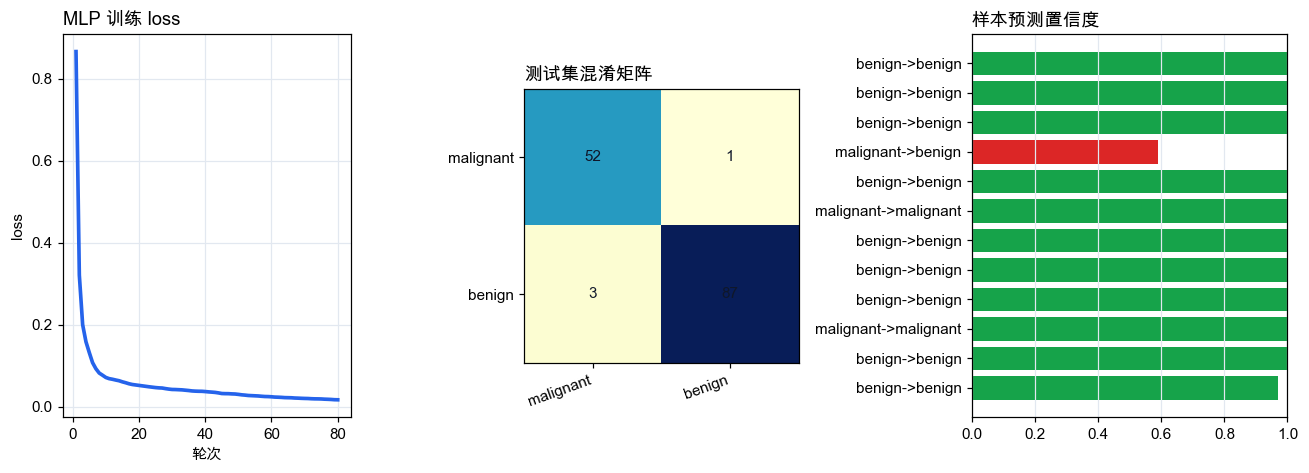

In [5]:
# 绘制 loss 曲线、混淆矩阵和预测置信度。
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.4), gridspec_kw={"width_ratios": [1.05, 1.0, 1.15]})

axes[0].plot(mlp_trace["轮次"], mlp_trace["loss"], color="#2563eb", linewidth=2.4)
axes[0].set_title("MLP 训练 loss", loc="left", fontweight="bold")
axes[0].set_xlabel("轮次")
axes[0].set_ylabel("loss")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

im = axes[1].imshow(confusion_df.to_numpy(), cmap="YlGnBu")
axes[1].set_title("测试集混淆矩阵", loc="left", fontweight="bold")
axes[1].set_xticks([0, 1], cancer.target_names, rotation=20, ha="right")
axes[1].set_yticks([0, 1], cancer.target_names)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, int(confusion_df.iloc[i, j]), ha="center", va="center", color="#0f172a", fontweight="bold")

preview_df = sample_result.copy()
preview_df["标签"] = [cancer.target_names[int(v)] for v in preview_df["真实"]]
preview_df["预测标签"] = [cancer.target_names[int(v)] for v in preview_df["预测"]]
bar_colors = np.where(preview_df["真实"].to_numpy() == preview_df["预测"].to_numpy(), "#16a34a", "#dc2626")
axes[2].barh(np.arange(len(preview_df)), preview_df["预测置信度"], color=bar_colors)
axes[2].set_yticks(np.arange(len(preview_df)), [f"{a}->{b}" for a, b in zip(preview_df["标签"], preview_df["预测标签"])])
axes[2].invert_yaxis()
axes[2].set_xlim(0, 1)
axes[2].set_title("样本预测置信度", loc="left", fontweight="bold")
axes[2].grid(True, axis="x", color="#e2e8f0", linewidth=0.8)

plt.tight_layout()
plt.show()